In [2]:
pip install tensorflow scikit-learn opencv-python pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.utils import to_categorical

In [4]:
CSV_PATH = "archive/data.csv"
IMAGE_DIR = "archive/image"
df = pd.read_csv(CSV_PATH)
print(df.head())
print(df.columns)

   Unnamed: 0         image       classes
0           0  image/0.jpeg       unknown
1           1  image/1.jpeg     head_lamp
2           2  image/2.jpeg  door_scratch
3           3  image/3.jpeg     head_lamp
4           4  image/4.jpeg       unknown
Index(['Unnamed: 0', 'image', 'classes'], dtype='object')


In [ ]:
import pandas as pd
df = pd.read_csv("archive/data.csv")
print(df.head())
print(df.columns)

   Unnamed: 0         image       classes
0           0  image/0.jpeg       unknown
1           1  image/1.jpeg     head_lamp
2           2  image/2.jpeg  door_scratch
3           3  image/3.jpeg     head_lamp
4           4  image/4.jpeg       unknown
Index(['Unnamed: 0', 'image', 'classes'], dtype='object')


In [ ]:
import os
IMAGE_DIR = "archive/image"
image_column = df.columns[0] 
df["image_path"] = df[image_column].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpeg")
)
print(df["image_path"].head())
print(os.path.exists(df["image_path"].iloc[0]))

0    archive/image\0.jpeg
1    archive/image\1.jpeg
2    archive/image\2.jpeg
3    archive/image\3.jpeg
4    archive/image\4.jpeg
Name: image_path, dtype: object
True


In [18]:
df = df[df["image_path"].apply(os.path.exists)]
print("Total valid samples:", len(df))

Total valid samples: 1512


In [ ]:
#data preprocessing
import cv2
import numpy as np
IMG_SIZE = 224
images = []
labels = []
for i, row in df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    images.append(img)
    labels.append(row["classes"])
X = np.array(images)
y = np.array(labels)
print(X.shape)

(1512, 224, 224, 3)


In [ ]:
#encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(encoder.classes_)

['bumper_dent' 'bumper_scratch' 'door_dent' 'door_scratch' 'glass_shatter'
 'head_lamp' 'tail_lamp' 'unknown']


In [ ]:
#Train/validtaion/Test Split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1209, 224, 224, 3)
Validation: (151, 224, 224, 3)
Test: (152, 224, 224, 3)


In [ ]:
#Prepare Data for ML Baselines
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_flat, y_train)
pred = rf.predict(X_test_flat)
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average="weighted"))
print("Recall:", recall_score(y_test, pred, average="weighted"))
print("F1:", f1_score(y_test, pred, average="weighted"))

Accuracy: 0.4934210526315789
Precision: 0.5246100329413167
Recall: 0.4934210526315789
F1: 0.4102681472199016


c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:

                precision    recall  f1-score   support

   bumper_dent       0.00      0.00      0.00        13
bumper_scratch       0.00      0.00      0.00         8
     door_dent       0.32      0.45      0.38        20
  door_scratch       1.00      0.19      0.32        16
 glass_shatter       0.60      0.23      0.33        13
     head_lamp       0.00      0.00      0.00        13
     tail_lamp       0.54      0.50      0.52        14
       unknown       0.52      0.96      0.68        55

      accuracy                           0.49       152
     macro avg       0.37      0.29      0.28       152
  weighted avg       0.44      0.49      0.40       152



c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

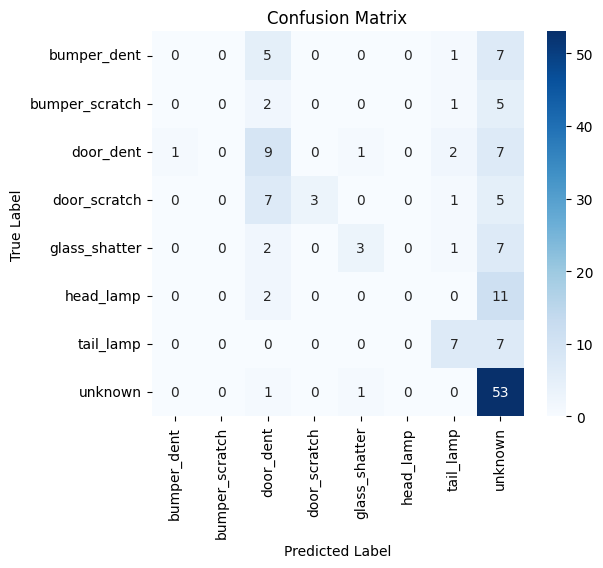

In [30]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("Classification Report:\n")
print(classification_report(y_test, pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [29]:
#SVM

from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_flat, y_train)
pred = svm.predict(X_test_flat)
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average="weighted"))
print("Recall:", recall_score(y_test, pred, average="weighted"))
print("F1:", f1_score(y_test, pred, average="weighted"))

Accuracy: 0.4934210526315789
Precision: 0.43648331802356566
Recall: 0.4934210526315789
F1: 0.4031511982455487


c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:

                precision    recall  f1-score   support

   bumper_dent       0.00      0.00      0.00        13
bumper_scratch       0.00      0.00      0.00         8
     door_dent       0.32      0.45      0.38        20
  door_scratch       1.00      0.19      0.32        16
 glass_shatter       0.60      0.23      0.33        13
     head_lamp       0.00      0.00      0.00        13
     tail_lamp       0.54      0.50      0.52        14
       unknown       0.52      0.96      0.68        55

      accuracy                           0.49       152
     macro avg       0.37      0.29      0.28       152
  weighted avg       0.44      0.49      0.40       152



c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

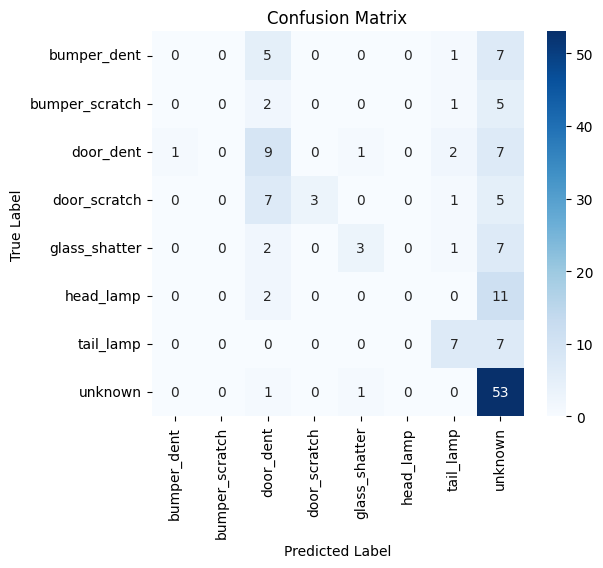

In [31]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("Classification Report:\n")
print(classification_report(y_test, pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Logistic Regression 

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_flat, y_train)
pred = lr.predict(X_test_flat)
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average="weighted"))
print("Recall:", recall_score(y_test, pred, average="weighted"))
print("F1:", f1_score(y_test, pred, average="weighted"))

Accuracy: 0.35526315789473684
Precision: 0.40898261860591184
Recall: 0.35526315789473684
F1: 0.3746327977438691


Classification Report:

                precision    recall  f1-score   support

   bumper_dent       0.00      0.00      0.00        13
bumper_scratch       0.00      0.00      0.00         8
     door_dent       0.32      0.45      0.38        20
  door_scratch       1.00      0.19      0.32        16
 glass_shatter       0.60      0.23      0.33        13
     head_lamp       0.00      0.00      0.00        13
     tail_lamp       0.54      0.50      0.52        14
       unknown       0.52      0.96      0.68        55

      accuracy                           0.49       152
     macro avg       0.37      0.29      0.28       152
  weighted avg       0.44      0.49      0.40       152



c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

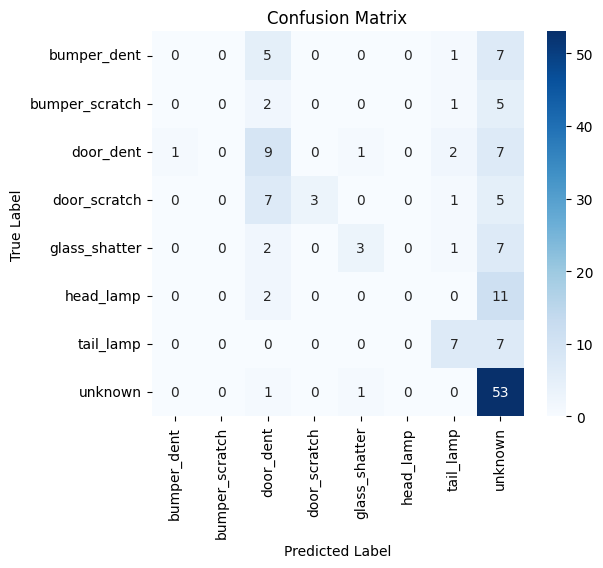

In [32]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("Classification Report:\n")
print(classification_report(y_test, pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=200)
}